In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://uk.wikipedia.org/wiki/%D0%9D%D0%B0%D1%81%D0%B5%D0%BB%D0%B5%D0%BD%D0%BD%D1%8F_%D0%A3%D0%BA%D1%80%D0%B0%D1%97%D0%BD%D0%B8"
headers = {'User-Agent': 'Mozilla/5.0'}

df = pd.read_html(url, match="Коефіцієнт народжуваності в регіонах України", storage_options=headers)[0]

In [2]:
df.head()

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,230.0,206.0,160.0,130,73,126,—,—
1,Вінницька,224.0,192.0,142.0,124,84,112,109,76
2,Волинська,247.0,250.0,179.0,153,112,148,141,101
3,Дніпропетровська,204.0,204.0,151.0,123,71,112,111,71
4,Донецька,271.0,214.0,140.0,109,61,98,82,—


In [3]:
df.shape

(28, 9)

In [4]:
df.replace(["—", "-"], np.nan, inplace=True)

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,230.0,206.0,160.0,130,73,126,NaN,NaN
1,Вінницька,224.0,192.0,142.0,124,84,112,109,76
2,Волинська,247.0,250.0,179.0,153,112,148,141,101
3,Дніпропетровська,204.0,204.0,151.0,123,71,112,111,71
4,Донецька,271.0,214.0,140.0,109,61,98,82,NaN
5,Житомирська,261.0,223.0,159.0,129,89,122,120,79
6,Закарпатська,314.0,273.0,207.0,168,115,151,146,104
7,Запорізька,219.0,197.0,150.0,124,71,106,106,68
8,Івано-Франківська,243.0,248.0,182.0,155,103,124,122,88
9,Київська,204.0,189.0,156.0,123,73,122,121,80


In [5]:
df.dtypes

Регіон        str
1950      float64
1960      float64
1970      float64
1990        int64
2000        int64
2012        int64
2014          str
2019          str
dtype: object

In [6]:
df = df.astype({"1950": "float64", "1960": "float64", "1970": "float64", "2014": "float64", "2019": "float64"})

In [7]:
nan_part = df.isnull().sum() / len(df)
nan_part

Регіон    0.000000
1950      0.071429
1960      0.035714
1970      0.035714
1990      0.000000
2000      0.000000
2012      0.000000
2014      0.071429
2019      0.142857
dtype: float64

In [8]:
df.drop(df[df["Регіон"] == "Україна"].index, inplace=True)

In [11]:
df.fillna(df.mean(numeric_only=True), inplace=True)

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,230.00,206.000000,160.0,130,73,126,111.44,80.173913
1,Вінницька,224.00,192.000000,142.0,124,84,112,109.00,76.000000
2,Волинська,247.00,250.000000,179.0,153,112,148,141.00,101.000000
3,Дніпропетровська,204.00,204.000000,151.0,123,71,112,111.00,71.000000
4,Донецька,271.00,214.000000,140.0,109,61,98,82.00,80.173913
5,Житомирська,261.00,223.000000,159.0,129,89,122,120.00,79.000000
6,Закарпатська,314.00,273.000000,207.0,168,115,151,146.00,104.000000
7,Запорізька,219.00,197.000000,150.0,124,71,106,106.00,68.000000
8,Івано-Франківська,243.00,248.000000,182.0,155,103,124,122.00,88.000000
9,Київська,204.00,189.000000,156.0,123,73,122,121.00,80.000000


In [16]:
regions_above_avg = df[df["2019"] > df["2019"].mean()]["Регіон"]
regions_above_avg

2             Волинська
6          Закарпатська
8     Івано-Франківська
12            Львівська
14              Одеська
16           Рівненська
20           Херсонська
23          Чернівецька
25                 Київ
Name: Регіон, dtype: str

In [24]:
region_max_2014 = df[df["2014"] == df["2014"].max()]["Регіон"]
region_max_2014

16    Рівненська
Name: Регіон, dtype: str

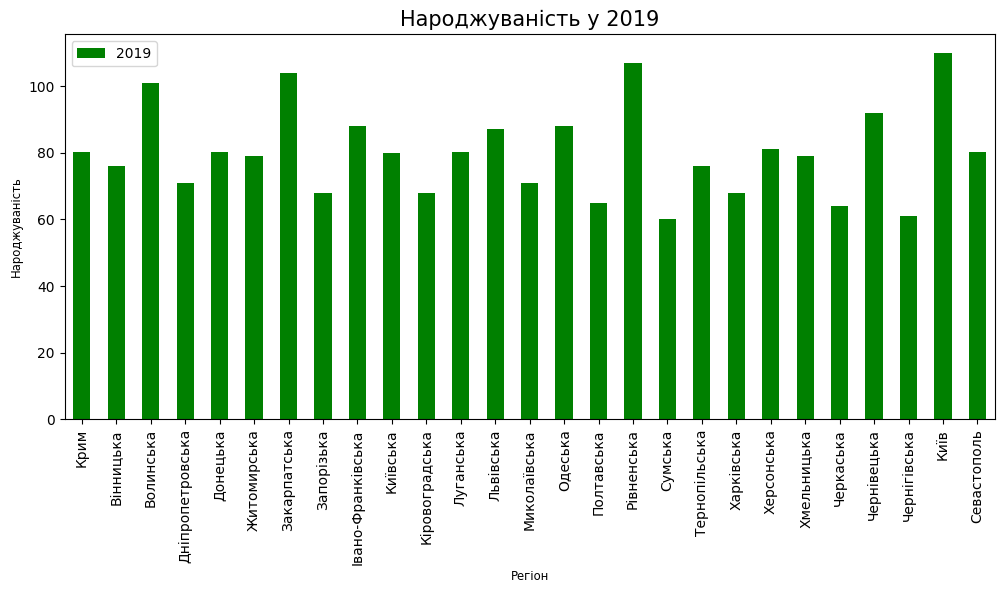

In [57]:
df_2019 = df[["Регіон", "2019"]]
df.plot.bar(x="Регіон", y="2019", figsize=[12, 5], color="green")
plt.title("Народжуваність у 2019", fontsize=15)
plt.xlabel("Регіон", fontsize="small")
plt.ylabel("Народжуваність", fontsize="small")
plt.show()

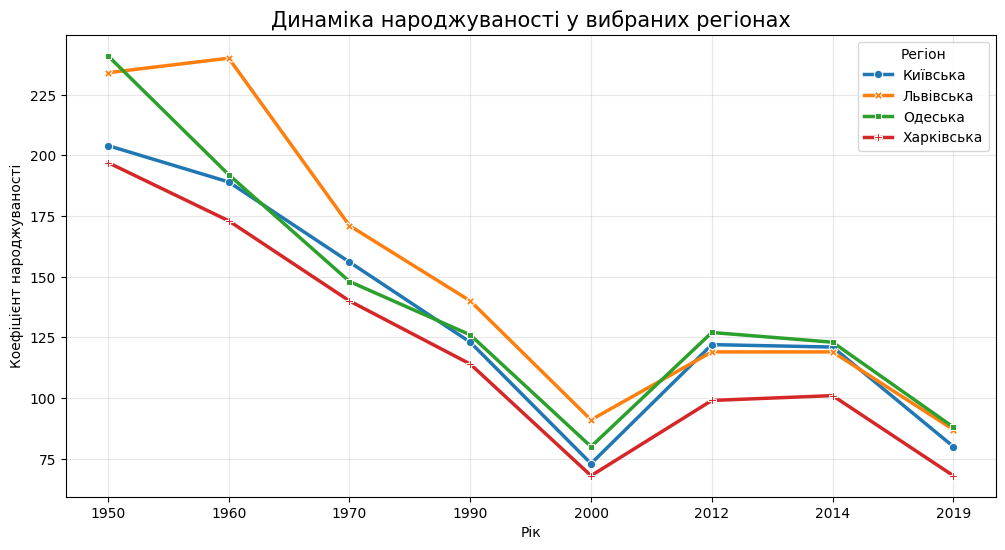

In [59]:
regions_to_plot = ['Київська', 'Львівська', 'Харківська', 'Одеська']
df_filtered = df[df['Регіон'].isin(regions_to_plot)]

years = ['1950', '1960', '1970', '1990', '2000', '2012', '2014', '2019']
df_plot = df_filtered.set_index('Регіон')[years].T

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_plot, markers=True, dashes=False, linewidth=2.5)

plt.title('Динаміка народжуваності у вибраних регіонах', fontsize=15)
plt.xlabel('Рік')
plt.ylabel('Коефіцієнт народжуваності')
plt.grid(True, alpha=0.3)
plt.show()

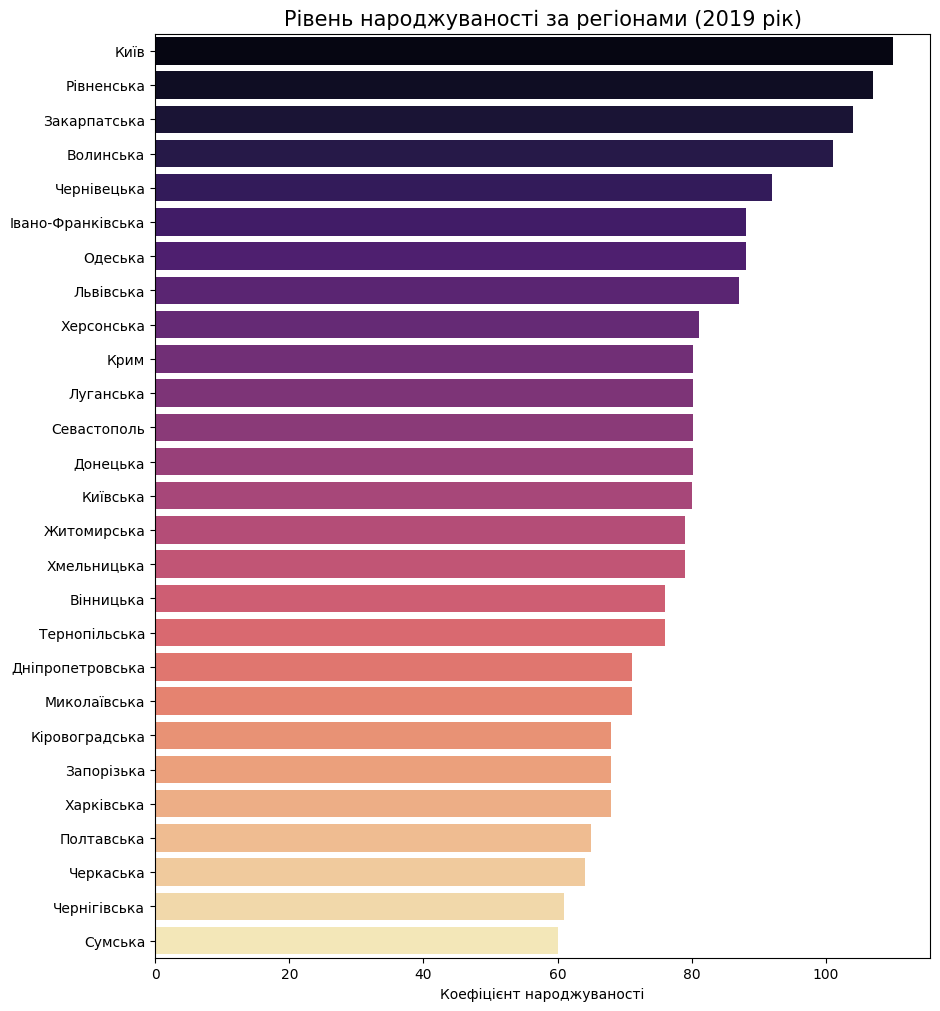

In [60]:
plt.figure(figsize=(10, 12))

df_sorted = df.sort_values('2019', ascending=False)

sns.barplot(x='2019', y='Регіон', data=df_sorted, hue='Регіон', palette='magma', legend=False)

plt.title('Рівень народжуваності за регіонами (2019 рік)', fontsize=15)
plt.xlabel('Коефіцієнт народжуваності')
plt.ylabel('')
plt.show()

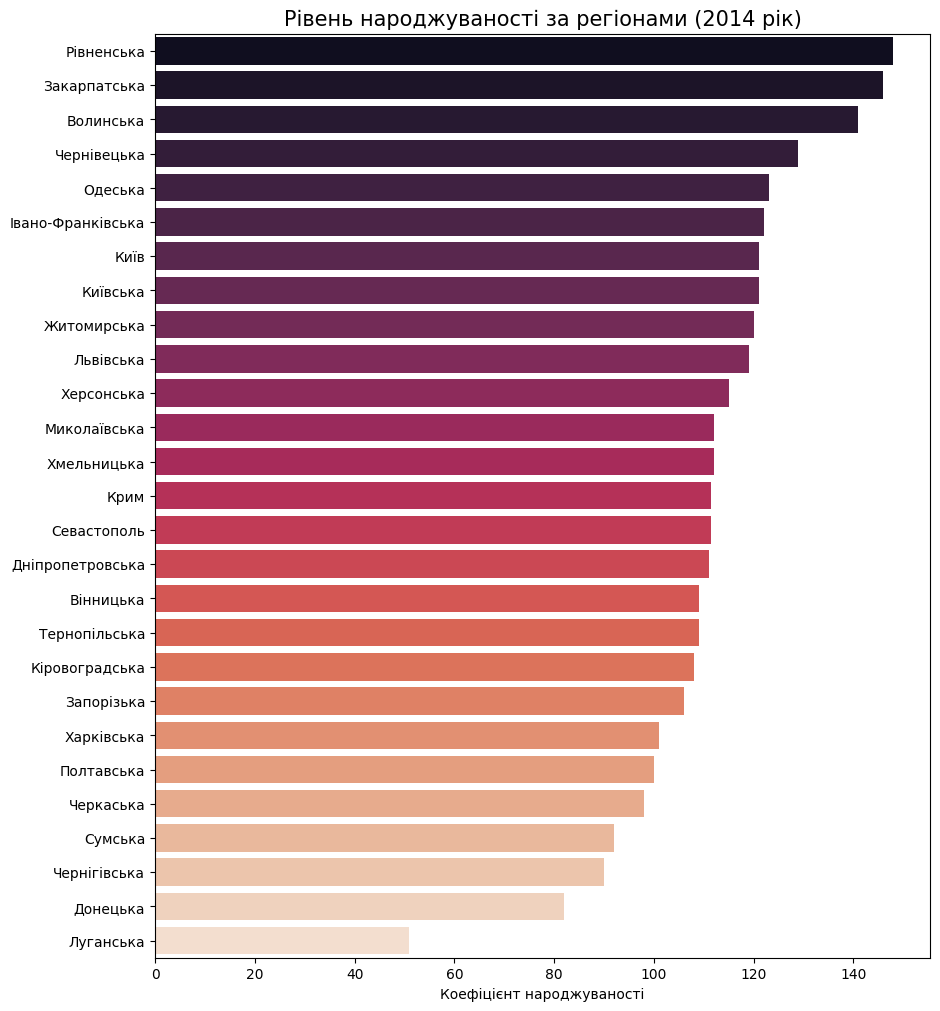

In [65]:
plt.figure(figsize=(10, 12))

df_sorted = df.sort_values('2014', ascending=False)

sns.barplot(x='2014', y='Регіон', data=df_sorted, hue='Регіон', palette='rocket', legend=False)

plt.title('Рівень народжуваності за регіонами (2014 рік)', fontsize=15)
plt.xlabel('Коефіцієнт народжуваності')
plt.ylabel('') # Прибираємо зайвий підпис "Регіон"
plt.show()